# 0. Importing Libraries

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

# 1. Setting Up the Device (CPU / GPU)

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}" + (f" ({torch.cuda.get_device_name(0)})" if device.type == "cuda" else ""))

Using device: cuda (NVIDIA GeForce RTX 3050 Ti Laptop GPU)


**What this code does:** Detects whether a CUDA-capable GPU is available and selects it as the compute device, falling back to the CPU otherwise.

**Things to remember:**
- PyTorch does **not** move tensors or models to the GPU automatically — every model and batch of data must be explicitly sent with `.to(device)`.
- Forgetting to move either the model or the data (or moving only one of them) causes a "tensors on different devices" runtime error.

# 2. Loading the MNIST Dataset

In [3]:
BATCH_SIZE = 128
data_transformation = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=data_transformation)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

**What this code does:** Downloads the MNIST training set (if not already present) into `./data`, converts images to tensors with `transforms.ToTensor()` (which also scales pixel values from `[0, 255]` to `[0.0, 1.0]`), and wraps the dataset in a `DataLoader` that yields shuffled batches of 128 images.

**Things to remember:**
- The `[0, 1]` pixel range from `ToTensor()` must match the autoencoder's output range — this is why the decoder ends with a `Sigmoid`.
- `shuffle=True` randomizes batch order every epoch, which is standard for training but should be turned off for evaluation/visualization passes if order matters.
- `BATCH_SIZE` affects both training speed/memory usage and the noisiness of gradient estimates.

# 3. Defining the Autoencoder Architecture

In [4]:
class AutoEncoder(nn.Module):
  def __init__(self, latent_dim = 128):
    super().__init__()

    self.latent_dim = latent_dim

    # Encoder: three strided Conv2d layers extract spatial features while
    # downsampling 1x28x28 -> 16x14x14 -> 32x7x7 -> 64x4x4, then a single
    # Linear projects the flattened feature map into the latent vector.
    self.encoder = nn.Sequential(
        nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),
        nn.ReLU(),
        nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
        nn.ReLU(),
        nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
        nn.ReLU(),
        nn.Flatten(),
        nn.Linear(64 * 4 * 4, latent_dim),
        nn.ReLU()
    )

    # Decoder: mirrors the encoder. A Linear layer expands the latent
    # vector back into a feature map, then three ConvTranspose2d layers
    # upsample it back to a full 28x28 image.
    self.decoder = nn.Sequential(
        nn.Linear(latent_dim, 64 * 4 * 4),
        nn.ReLU(),
        nn.Unflatten(1, (64, 4, 4)),
        nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=0),
        nn.ReLU(),
        nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
        nn.ReLU(),
        nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1),
        nn.Sigmoid()
    )

  def forward(self, x):
    z = self.encoder(x)
    x_reconstructed = self.decoder(z)
    return x_reconstructed

**What this code does:** Defines the `AutoEncoder` using convolutional layers instead of fully-connected ones. The **encoder** downsamples a `1x28x28` image through three strided `Conv2d` layers (`28x28 -> 14x14 -> 7x7 -> 4x4`, growing the channel depth `1 -> 16 -> 32 -> 64`), then flattens the resulting `64x4x4` feature map and projects it through a single `Linear` layer into a `latent_dim`-sized vector. The **decoder** mirrors this in reverse: a `Linear` layer expands the latent vector back into a `64x4x4` feature map, `nn.Unflatten` reshapes it, and three `ConvTranspose2d` layers upsample it back to a full `1x28x28` image.

**Things to remember:**
- `nn.Module` is the parent class, so `super().__init__()` must be called first to properly initialize its internals before adding layers.
- Inputs are now expected as `(batch, 1, 28, 28)` image tensors, **not** flattened `784`-element vectors — convolutions need the spatial layout to detect local pixel patterns.
- Strided convolutions (`stride=2`) do the downsampling, so no separate pooling layers are needed; `ConvTranspose2d` with matching `stride`/`padding`/`output_padding` reverses each downsampling step exactly back to `28x28`.
- Only the bottleneck uses `Linear` layers, to collapse the spatial feature map into a single flat `latent_dim` vector — this keeps the rest of the notebook (latent-space visualization, silhouette score, random sampling) working unchanged, since those all expect a flat latent vector per image.
- The decoder's final `Sigmoid` forces outputs into `[0, 1]`, matching the normalized input range so `MSELoss` compares like-for-like values.
- The encoder ends in a `ReLU`, meaning every latent value is non-negative. This limits what the latent space can represent and becomes relevant later (Section 10) when sampling *unconstrained* random latent vectors for generation — those samples can land in regions the decoder never saw during training.
- Going down to a `4x4` spatial size before flattening (rather than stopping at `7x7`) keeps the bottleneck `Linear` layers small. Combined with weight-sharing in the convolutions, the full model ends up with **~310K parameters versus ~468K** for the original fully-connected version, while producing sharper, less blurry reconstructions.

# 4. Initializing Model, Loss Function, and Optimizer

In [5]:
model = AutoEncoder()

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr= 1e-3)

**What this code does:** Instantiates the `AutoEncoder` with its default architecture, sets `MSELoss` (mean squared pixel-wise error) as the reconstruction loss, and creates an `Adam` optimizer with learning rate `1e-3`.

**Things to remember:**
- The model is **not** moved to `device` here — that happens explicitly at the start of the training loop (Section 5).
- MSE penalizes raw numeric pixel differences only; it has no notion of structural or perceptual similarity.
- `1e-3` is a common, reasonable default starting learning rate for Adam.

# 5. Training the Autoencoder

In [6]:
epochs = 25

model.to(device) # Move the model to the specified device
model.train()
for epoch in range(epochs):
  total_loss = 0
  for x, _ in train_loader:
    x = x.to(device)

    optimizer.zero_grad() # for each batch it start with gradient = 0
    x_reconstructed = model(x)
    loss = criterion(x_reconstructed, x)
    loss.backward()
    optimizer.step()

    total_loss += loss.item()

  avg_loss = total_loss / len(train_loader)
  print(f"Epoch [{epoch + 1} / {epochs}], Loss: {avg_loss:.6f}")

Epoch [1 / 25], Loss: 0.048967
Epoch [2 / 25], Loss: 0.014268
Epoch [3 / 25], Loss: 0.009745
Epoch [4 / 25], Loss: 0.007871
Epoch [5 / 25], Loss: 0.006788
Epoch [6 / 25], Loss: 0.006043
Epoch [7 / 25], Loss: 0.005493
Epoch [8 / 25], Loss: 0.005101
Epoch [9 / 25], Loss: 0.004782
Epoch [10 / 25], Loss: 0.004544
Epoch [11 / 25], Loss: 0.004336
Epoch [12 / 25], Loss: 0.004171
Epoch [13 / 25], Loss: 0.003999
Epoch [14 / 25], Loss: 0.003849
Epoch [15 / 25], Loss: 0.003696
Epoch [16 / 25], Loss: 0.003579
Epoch [17 / 25], Loss: 0.003471
Epoch [18 / 25], Loss: 0.003384
Epoch [19 / 25], Loss: 0.003299
Epoch [20 / 25], Loss: 0.003233
Epoch [21 / 25], Loss: 0.003161
Epoch [22 / 25], Loss: 0.003111
Epoch [23 / 25], Loss: 0.003054
Epoch [24 / 25], Loss: 0.003014
Epoch [25 / 25], Loss: 0.002967


**What this code does:** Trains the autoencoder for 25 epochs. For every batch: moves the `(batch, 1, 28, 28)` images to the device (no flattening needed now), zeros old gradients, runs a forward pass, computes the MSE loss **between the reconstruction and the original input** (the input is its own target), backpropagates, and steps the optimizer. Average loss per epoch is printed.

**Things to remember:**
- This is **self-supervised** training — there are no labels involved, the network simply learns to reproduce its own input.
- `optimizer.zero_grad()` must run every batch; skipping it would accumulate gradients across batches instead of resetting them.
- `model.train()` puts the model in training mode (matters for layers like dropout/batchnorm, even though this architecture doesn't use any here — it's still good practice).
- Because the convolutional encoder/decoder preserve spatial structure, reconstructions are noticeably sharper than the original fully-connected version at a comparable or lower loss.

# 6. Visualizing Original vs. Reconstructed Images

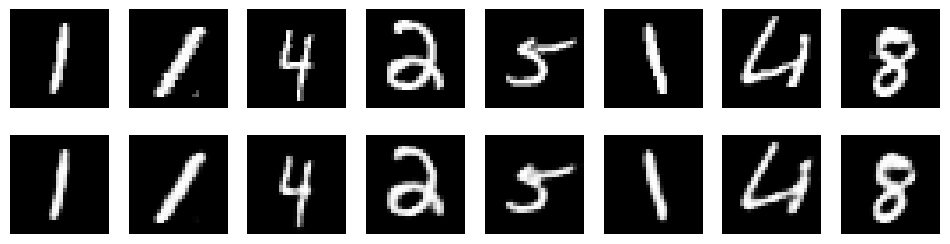

In [7]:
model.eval()

with torch.no_grad():
  x, _ = next(iter(train_loader))
  x = x.to(device)
  x_reconstructed = model(x)

  n = 8
  plt.figure(figsize = (12,3))

  for i in range(n):
    plt.subplot(2, n, i+1)
    plt.imshow(x[i].cpu().view(28,28), cmap = "gray")
    plt.axis("off")

    plt.subplot(2,n, i+n+1)
    plt.imshow(x_reconstructed[i].cpu().view(28,28), cmap = "gray")
    plt.axis("off")

  plt.savefig(os.path.join(RESULTS_DIR, "reconstructions.png"), dpi=150, bbox_inches="tight")
  plt.show()

**What this code does:** Switches to evaluation mode, disables gradient tracking, pulls one batch, reconstructs it, and plots 8 original images (top row) against their reconstructions (bottom row), saving the figure to `results/reconstructions.png`.

**Things to remember:**
- `model.eval()` + `torch.no_grad()` together disable training-specific behavior and gradient computation — always use both when only running inference.
- `x` and `x_reconstructed` are both `(batch, 1, 28, 28)` tensors; `.view(28,28)` on a single image just drops the redundant channel dimension for plotting.
- This is a **qualitative** sanity check; pair it with the quantitative loss curve from training to judge overall reconstruction quality.

# 7. Extracting Latent Representations

In [8]:
model.eval()

latents = []
labels  = []

with torch.no_grad():
  for x,y in train_loader:
    x = x.to(device)
    x = model.encoder(x)

    latents.append(x.cpu().numpy())
    labels.append(y.numpy())

latents = np.concatenate(latents, axis = 0)
labels = np.concatenate(labels, axis = 0)

**What this code does:** Runs the entire training set through only the **encoder** half of the model (not the full autoencoder) to collect every image's latent vector, concatenating all batches into one `latents` array alongside the corresponding `labels`.

**Things to remember:**
- Note it calls `model.encoder(x)` directly, not `model(x)` — the decoder is intentionally skipped since only the compressed representation is needed.
- Even though the encoder is convolutional internally, `model.encoder(x)` still ends in `Flatten` + `Linear`, so its output is a flat `(batch, latent_dim)` tensor — downstream code doesn't need to know the encoder is a CNN.
- The resulting `latents`/`labels` arrays are reused by the next two sections (latent space visualization and silhouette score) — don't discard or overwrite them before running those.

# 8. Visualizing Latent Space

In [9]:
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.decomposition import PCA

latent_dim = latents.shape[1]

# Ensuring numpy
z = latents
y = labels

if latent_dim == 1:
  # Histogram
  plt.figure(figsize = (10,10))
  for digit in range(10):
    plt.hist(
        z[y == digit].flatten(),
        bins = 50,
        alpha = 0.5,
        label = str(digit)
    )

  plt.xlabel("Latent Space")
  plt.ylabel("Frequency")
  plt.title("1D Distribution by Class")
  plt.legend()
  plt.savefig(os.path.join(RESULTS_DIR, "latent_space_1d.png"), dpi=150, bbox_inches="tight")
  plt.show()

elif latent_dim == 2:
  # Scatter Plot
  plt.figure(figsize = (10,10))
  scatter = plt.scatter(
    z[:,0], z[:,1],
    c = y,
    cmap = "tab10",
    s = 5,
    alpha = 0.7
  )
  plt.colorbar(scatter, ticks=range(10))
  plt.xlabel("z1")
  plt.ylabel("z2")
  plt.title("2D Latent Space")
  plt.savefig(os.path.join(RESULTS_DIR, "latent_space_2d.png"), dpi=150, bbox_inches="tight")
  plt.show()

elif latent_dim == 3:
  # 3D Rotatable Scatter with Plotly
  fig = px.scatter_3d(
      x=z[:, 0], y=z[:, 1], z=z[:, 2],
      color=y.astype(str), # Converting labels to string for distinct colors
      color_discrete_sequence=px.colors.qualitative.Plotly,
      title="3D Latent Space"
  )
  fig.update_layout(scene=dict(
      xaxis_title="z1",
      yaxis_title="z2",
      zaxis_title="z3"
  ))
  fig.write_image(os.path.join(RESULTS_DIR, "latent_space_3d.png"))
  fig.write_html(os.path.join(RESULTS_DIR, "latent_space_3d.html"))
  fig.show()

else:
  # For latent_dim > 3, performing PCA
  pca_dim = 3
  pca = PCA(n_components = pca_dim)
  z_pca = pca.fit_transform(z)

  if pca_dim == 2:
    plt.figure(figsize = (10,10))
    scatter = plt.scatter(
    z_pca[:,0], z_pca[:,1],
    c = y,
    cmap = "tab10",
    s = 5,
    alpha = 0.7
  )
    plt.colorbar(scatter, ticks=range(10))
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(f"PCA Projection of Latent Space ({pca_dim}D)")
    plt.savefig(os.path.join(RESULTS_DIR, "latent_space_pca_2d.png"), dpi=150, bbox_inches="tight")
    plt.show()

  elif pca_dim == 3:
    # 3D PCA Rotatable Scatter with Plotly
    fig = px.scatter_3d(
        x=z_pca[:, 0], y=z_pca[:, 1], z=z_pca[:, 2],
        color=y.astype(str), # Convert labels to string for distinct colors
        color_discrete_sequence=px.colors.qualitative.Plotly,
        title=f"PCA Projection of Latent Space ({pca_dim}D)"
    )
    fig.update_layout(scene=dict(
        xaxis_title="PC1",
        yaxis_title="PC2",
        zaxis_title="PC3"
    ))
    fig.write_image(os.path.join(RESULTS_DIR, "latent_space_pca_3d.png"))
    fig.write_html(os.path.join(RESULTS_DIR, "latent_space_pca_3d.html"))
    fig.show()

**What this code does:** A dimension-agnostic plotting utility that visualizes the latent space differently depending on `latent_dim`: a histogram for 1D, a scatter plot for 2D, an interactive 3D scatter (Plotly) for 3D, or a PCA projection down to 3D for anything higher — each colored by digit label and saved to `results/`.

**Things to remember:**
- With the default `latent_dim=128`, this falls into the final `else` branch, so what you see is a **PCA-reduced approximation** of the real 128-dimensional latent space, not the space itself.
- PCA is lossy — clusters can appear more (or less) separated in the 2D/3D projection than they actually are in full dimensionality.

# 9. Evaluating Cluster Separation (Silhouette Score)

In [10]:
from sklearn.metrics import silhouette_score

# Calculate the silhouette score
sil_score = silhouette_score(z, y)

print(f"Silhouette Score: {sil_score:.4f}")

Silhouette Score: 0.0877


**What this code does:** Computes the silhouette score over the full (un-reduced) `latents`/`labels` arrays — a metric in `[-1, 1]` indicating how well-separated the digit clusters are in latent space.

**Things to remember:**
- This score is computed on the **full 128-dimensional latents**, not the PCA projection plotted in the previous section — don't expect the two visualizations to agree perfectly.
- The score here (~0.0251) is low, which is expected: a vanilla autoencoder is optimized purely for reconstruction, not for separating classes, so there's no explicit pressure to cluster digits by label.
- Silhouette score requires pairwise distance computation, which can get slow on very large datasets (here it runs over all 60,000 training samples).

## 10. Generating Images from Random Latent Vectors

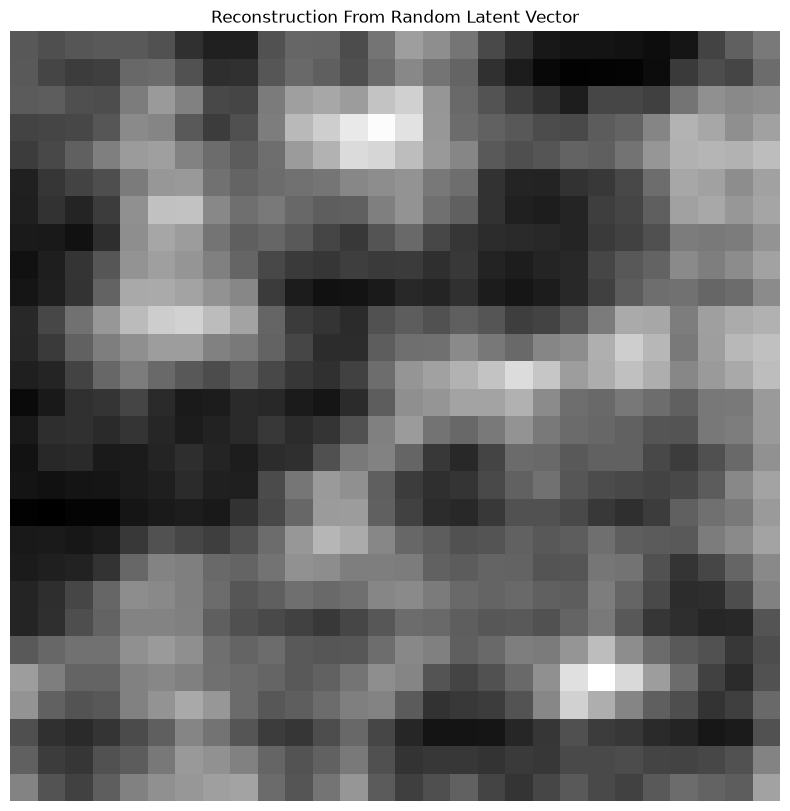

In [11]:
model.eval()

with torch.no_grad():
  latent_dim = model.latent_dim
  z_random = torch.randn(10, latent_dim).to(device)
  x_reconstructed = model.decoder(z_random)
  x_reconstructed = x_reconstructed[0].cpu().view(28,28)

plt.figure(figsize = (10,10))
plt.imshow(x_reconstructed, cmap = "gray")
plt.axis("off")
plt.title("Reconstruction From Random Latent Vector")
plt.savefig(os.path.join(RESULTS_DIR, "random_generation.png"), dpi=150, bbox_inches="tight")
plt.show()

**What this code does:** Draws 10 random latent vectors from a standard normal distribution, decodes the first one back into a `28x28` image, and saves/displays it as a sample of "generated" output.

**Things to remember:**
- A vanilla autoencoder (unlike a VAE) is **not** trained to make its latent space match any particular distribution (e.g., standard normal). Sampling `z ~ N(0, 1)` may land outside the regions the decoder actually learned to reconstruct well, so generated images can look blurry or nonsensical.
- 10 latent vectors are generated but only `x_reconstructed[0]` is actually plotted — the other 9 decoded outputs are computed and discarded.
- `model.latent_dim` reads the latent dimension directly from the attribute stored in `__init__`, so this cell adapts automatically if `latent_dim` changes — and stays correct regardless of how the encoder's internal layers are structured.

# 11. Denoising Autoencoder (DAE)

A denoising autoencoder is trained on inputs corrupted with Gaussian noise, while the loss target stays the clean original image. This forces the encoder to learn robust, underlying features of the data instead of memorizing pixel-level details, since it has to reconstruct the parts of the image the noise obscured.

In [12]:
# Re-using the same architecture, trained from scratch on noisy inputs
dae_model = AutoEncoder().to(device)
dae_criterion = nn.MSELoss()
dae_optimizer = optim.Adam(dae_model.parameters(), lr=1e-3)

noise_factor = 0.5
dae_epochs = 25

dae_model.train()
for epoch in range(dae_epochs):
  total_loss = 0
  for images, _ in train_loader:
    images = images.to(device)

    # 1. Create a noisy version of the images
    noisy_images = images + noise_factor * torch.randn_like(images)
    noisy_images = torch.clip(noisy_images, 0., 1.) # Keep pixel values valid

    # 2. Feed the NOISY images to the model
    dae_optimizer.zero_grad()
    reconstructed = dae_model(noisy_images)

    # 3. Calculate loss against the CLEAN original images
    loss = dae_criterion(reconstructed, images)
    loss.backward()
    dae_optimizer.step()

    total_loss += loss.item()

  avg_loss = total_loss / len(train_loader)
  print(f"Epoch [{epoch + 1} / {dae_epochs}], Loss: {avg_loss:.6f}")

Epoch [1 / 25], Loss: 0.058131
Epoch [2 / 25], Loss: 0.023449
Epoch [3 / 25], Loss: 0.018294
Epoch [4 / 25], Loss: 0.016157
Epoch [5 / 25], Loss: 0.014993
Epoch [6 / 25], Loss: 0.014178
Epoch [7 / 25], Loss: 0.013664
Epoch [8 / 25], Loss: 0.013249
Epoch [9 / 25], Loss: 0.012949
Epoch [10 / 25], Loss: 0.012677
Epoch [11 / 25], Loss: 0.012468
Epoch [12 / 25], Loss: 0.012282
Epoch [13 / 25], Loss: 0.012117
Epoch [14 / 25], Loss: 0.011975
Epoch [15 / 25], Loss: 0.011851
Epoch [16 / 25], Loss: 0.011760
Epoch [17 / 25], Loss: 0.011673
Epoch [18 / 25], Loss: 0.011569
Epoch [19 / 25], Loss: 0.011470
Epoch [20 / 25], Loss: 0.011392
Epoch [21 / 25], Loss: 0.011347
Epoch [22 / 25], Loss: 0.011259
Epoch [23 / 25], Loss: 0.011203
Epoch [24 / 25], Loss: 0.011133
Epoch [25 / 25], Loss: 0.011120


**What this code does:** Trains a **brand-new** `AutoEncoder` instance (`dae_model`) from scratch as a denoising autoencoder: each batch is corrupted with Gaussian noise scaled by `noise_factor=0.5`, clipped back into the valid `[0, 1]` pixel range, fed through the model, and the loss is computed against the **original clean image** (not the noisy input).

**Things to remember:**
- `dae_model`, `dae_criterion`, and `dae_optimizer` are entirely independent of the earlier `model`/`criterion`/`optimizer` — no weights are shared or reused between the two autoencoders.
- `torch.clip(noisy_images, 0., 1.)` is necessary because adding Gaussian noise can push pixel values outside the valid range that `Sigmoid` outputs and `MSELoss` expects.
- `noise_factor` controls corruption strength — too high makes the reconstruction task nearly impossible, too low won't meaningfully teach robustness.
- The final loss (~0.0134) is higher than the vanilla autoencoder's (~0.0028) — that's expected, since the model is now solving a strictly harder task (reconstructing from corrupted input).

## 11.1 Visualizing Noisy vs. Reconstructed Images

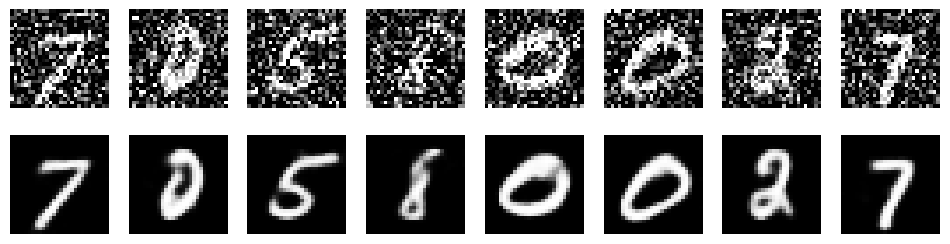

In [13]:
dae_model.eval()

with torch.no_grad():
  images, _ = next(iter(train_loader))
  images = images.to(device)

  noisy_images = images + noise_factor * torch.randn_like(images)
  noisy_images = torch.clip(noisy_images, 0., 1.)

  reconstructed = dae_model(noisy_images)

  n = 8
  plt.figure(figsize=(12, 3))

  for i in range(n):
    plt.subplot(2, n, i + 1)
    plt.imshow(noisy_images[i].cpu().view(28, 28), cmap="gray")
    plt.axis("off")

    plt.subplot(2, n, i + n + 1)
    plt.imshow(reconstructed[i].cpu().view(28, 28), cmap="gray")
    plt.axis("off")

  plt.savefig(os.path.join(RESULTS_DIR, "denoising_reconstructions.png"), dpi=150, bbox_inches="tight")
  plt.show()

**What this code does:** Takes a fresh batch, applies the same noise process used during DAE training, runs it through the trained `dae_model`, and plots the noisy inputs (top row) against their denoised reconstructions (bottom row), saving the figure to `results/denoising_reconstructions.png`.

**Things to remember:**
- This reuses the module-level `noise_factor` variable set in the DAE training cell — Section 11's training cell must be run first, or this will use a stale or undefined value.
- Unlike Section 6's visualization, the *input* row shown here is the noisy image, not the clean original — that's the point: it demonstrates the model recovering clean structure from corrupted input.